# Production Multi-Stage Root Count Prediction System

This notebook demonstrates the **production-ready prediction system** that goes beyond single model deployment to a complete decision system with:

## Key Features

1. **Multi-Stage Architecture**
   - Shared DepthAwareGATv2 backbone (preserves polynomial geometry)
   - CORAL ordinal regression head (safety layer)
   - Focal classification head (sharp predictions)
   
2. **Uncertainty-Aware Routing**
   - Defers low-confidence predictions
   - Routes to CORAL for ordinal stability
   - Routes to Focal for high-confidence sharp predictions
   
3. **Regime Detection & Drift Monitoring**
   - FAISS vector indexing of embeddings
   - Nearest centroid regime detection
   - k-NN distance for OOD detection
   
4. **Calibrated Confidence**
   - Expected Calibration Error (ECE)
   - Selective prediction curves
   - Threshold optimization on validation set
   
5. **Explainability**
   - k-NN retrieval for similar nodes
   - Decision explanations with confidence scores

## Pipeline Steps
1. Load environment and connect to Neo4j
2. Load graph data with full feature set
3. Train production model (two-phase: CORAL → Focal)
4. Fit regime detector and calibrate thresholds
5. Evaluate with routing metrics
6. Generate predictions with explanations
7. Monitor calibration and drift


In [17]:
# Force reload of modules to pick up code changes
import importlib
import sys

# Remove cached modules
modules_to_reload = [m for m in sys.modules.keys() if m.startswith('graph_label_prediction')]
for module in modules_to_reload:
    del sys.modules[module]

print(f"✓ Cleared {len(modules_to_reload)} cached modules")
print("  Now run the imports cell below to reload with latest code")

✓ Cleared 12 cached modules
  Now run the imports cell below to reload with latest code


## 1. Imports and Setup

In [18]:
import os
import sys
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split

# Add parent directory to path for pipeline modules
ml_path = Path('.').absolute().parent.parent
if str(ml_path) not in sys.path:
    sys.path.insert(0, str(ml_path))

# Add neo4j directory to path for neo4jClient
neo4j_path = ml_path / 'neo4j'
if str(neo4j_path) not in sys.path:
    sys.path.insert(0, str(neo4j_path))

# Import Neo4j client
from neo4jClient import Neo4jClient

# Import data loader
from graph_label_prediction.python_model.core.data_loader import GraphDataLoader
from graph_label_prediction import config

# Import production system components
from graph_label_prediction.python_model.production import (
    # Main training and prediction
    train_production_model,
    ProductionPredictor,
    create_predictor,
    
    # Model components
    ProductionRootClassifier,
    get_production_model,
    
    # Training
    ProductionTrainer,
    TrainingConfig,
    
    # Routing
    UncertaintyRouter,
    RoutingConfig,
    calibrate_thresholds,
    
    # Regime detection
    RegimeDetector,
    compute_regime_boundaries,
    
    # Calibration
    compute_calibration_metrics,
    selective_accuracy_curve,
    compute_selective_metrics,
    find_optimal_thresholds,
    temperature_scaling,
)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print("✓ Imports successful")

PyTorch version: 2.9.1+cpu
CUDA available: False
Device: cpu
✓ Imports successful


## 2. Load Environment Variables

In [19]:
# Load .env file from two levels up (ml/.env)
env_path = Path('.').absolute().parent.parent / '.env'
load_dotenv(env_path)
print(f"✓ Loaded .env from: {env_path}")

# Neo4j connection settings
NEO4J_URI = os.getenv('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER = os.getenv('NEO4J_USER', 'neo4j')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE', 'd4seed1')

if NEO4J_PASSWORD is None:
    raise ValueError("NEO4J_PASSWORD not found in .env file")

print("\nConnection Configuration:")
print(f"  URI: {NEO4J_URI}")
print(f"  User: {NEO4J_USER}")
print(f"  Password: {'*' * len(NEO4J_PASSWORD)}")
print(f"  Database: {NEO4J_DATABASE}")

✓ Loaded .env from: c:\Users\tomas\JavaProjects\Aibeceles\ml\.env

Connection Configuration:
  URI: bolt://localhost:7687
  User: neo4j
  Password: ***********
  Database: d4seed1


## 3. Connect to Neo4j and Load Graph Data

In [20]:
# Create Neo4j client
client = Neo4jClient(
    uri=NEO4J_URI,
    user=NEO4J_USER,
    password=NEO4J_PASSWORD
)
print("✓ Connected to Neo4j")

# Load graph data
loader = GraphDataLoader(client, database=NEO4J_DATABASE, use_filtering=True)
data = loader.load()

print("\n" + "="*60)
print("Graph Data Summary")
print("="*60)
print(f"Number of nodes: {data.num_nodes:,}")
print(f"Number of edges: {data.num_edges:,}")
print(f"Number of features: {data.num_features}")
print(f"Number of classes: {len(torch.unique(data.y))}")
print(f"Class distribution: {torch.bincount(data.y).tolist()}")
print(f"Determined nodes: {data.determined.sum().item():,} ({100*data.determined.float().mean():.1f}%)")
print("="*60)

✓ Connected to Neo4j
Using filtered queries (pArrayList ∈ [0, 5))...


Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: unknown property key. The property `windowMin` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=16, column=10, offset=500>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_status_parameters': {'propkey': 'windowMin'}, '_severity': 'WARNING', '_position': {'offset': 500, 'line': 16, 'column': 10}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (d:Dnode)-[:CreatedBye]->(cb:CreatedBy)\nWHERE all(x IN cb.pArrayList WHERE x >= 0 AND x < 5)\nRETURN elementId(d) as node_id,\n       coalesce(size(d.RootList), d.totalZero, 0) as label,\n       d.totalZero as totalZero,\n       d.RootList as RootList,\n       size(d.RootList) a

Computing spectral positional encodings for 3,775 nodes...
  Feature dim: 24 (16 base+coeff+stats+set_union + 8 spectral PE)

Graph Data Summary
Number of nodes: 3,775
Number of edges: 758
Number of features: 24
Number of classes: 5
Class distribution: [755, 1365, 1014, 407, 234]
Determined nodes: 2,906 (77.0%)


## 4. Configure Training

Note: The production trainer will create stratified train/val/test splits automatically based on the configuration.

## 5. Train Production Model (Two-Phase)

### Phase 1: Train Backbone + CORAL Head
- Goal: Learn embeddings that preserve polynomial relationship geometry
- CORAL respects ordinal structure (0 < 1 < 2 < 3 < 4)

### Phase 2: Train Focal Head (Frozen Backbone)
- Goal: Learn sharp decisions without destroying embeddings
- Focal loss handles class imbalance and focuses on hard examples

In [21]:
# Configure training
training_config = TrainingConfig(
    # Phase 1: CORAL
    phase1_epochs=150,
    phase1_patience=20,
    phase1_lr=0.001,
    phase1_weight_decay=1e-4,
    
    # Phase 2: Focal
    phase2_epochs=100,
    phase2_patience=15,
    phase2_lr=0.0005,
    phase2_weight_decay=1e-4,
    
    # Focal loss parameters
    focal_gamma=2.0,
    
    # Data splits
    holdout_fraction=0.15,  # Test set
    val_fraction=0.15,      # Validation from training
    
    # Early stopping
    min_epochs=10,
    
    # Class weighting (handles imbalance)
    use_class_weights=True,
    class_weight_method='sqrt',
)

print("Training Configuration:")
print(f"  Phase 1 epochs: {training_config.phase1_epochs} (patience: {training_config.phase1_patience})")
print(f"  Phase 2 epochs: {training_config.phase2_epochs} (patience: {training_config.phase2_patience})")
print(f"  Focal gamma: {training_config.focal_gamma}")
print(f"  Class weights: {training_config.class_weight_method if training_config.use_class_weights else 'None'}")
print("\nStarting training...\n")

# Train the model
model, trainer, metrics = train_production_model(
    data=data,
    config=training_config,
    verbose=True
)

print("\n" + "="*60)
print("Training Complete!")
print("="*60)
print("\nPhase 1 (CORAL) Metrics:")
for key, value in metrics['phase1'].items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")

print("\nPhase 2 (Focal) Metrics:")
for key, value in metrics['phase2'].items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
print("="*60)

# Extract the train/val/test masks created by the trainer
train_mask = trainer.train_mask
val_mask = trainer.val_mask
test_mask = trainer.test_mask

print("\nData Split Summary:")
print(f"  Train: {train_mask.sum().item():,} ({100*train_mask.float().mean():.1f}%)")
print(f"  Val:   {val_mask.sum().item():,} ({100*val_mask.float().mean():.1f}%)")
print(f"  Test:  {test_mask.sum().item():,} ({100*test_mask.float().mean():.1f}%)")

Training Configuration:
  Phase 1 epochs: 150 (patience: 20)
  Phase 2 epochs: 100 (patience: 15)
  Focal gamma: 2.0
  Class weights: sqrt

Starting training...

Phase 1: Training backbone + CORAL head
  Epoch 000 | Loss: 11.8456 | Train F1: 0.0666 | Val F1: 0.0665
  Epoch 010 | Loss: 18.2732 | Train F1: 0.1464 | Val F1: 0.1256
  Epoch 020 | Loss: 11.4761 | Train F1: 0.1654 | Val F1: 0.1528
  Epoch 030 | Loss: 2.6433 | Train F1: 0.1783 | Val F1: 0.1785
  Epoch 040 | Loss: 2.5043 | Train F1: 0.1430 | Val F1: 0.1375
  Epoch 050 | Loss: 2.6419 | Train F1: 0.1591 | Val F1: 0.1577
  Early stopping at epoch 51

Phase 1 Complete - Starting Phase 2 (Focal Head)

Phase 2: Training Focal head (frozen backbone)
  Epoch 000 | Loss: 2.0641 | Train F1: 0.2927 | Val F1: 0.2854
  Epoch 010 | Loss: 0.8583 | Train F1: 0.6070 | Val F1: 0.5848
  Epoch 020 | Loss: 0.5305 | Train F1: 0.6024 | Val F1: 0.5833
  Epoch 030 | Loss: 0.4017 | Train F1: 0.6319 | Val F1: 0.6193
  Epoch 040 | Loss: 0.3305 | Train F1:

## 6. Create Production Predictor with Routing

The predictor integrates:
- Trained model (CORAL + Focal heads)
- Regime detector (FAISS index)
- Uncertainty router (confidence-based routing)

In [22]:
# Create predictor using helper function
predictor = create_predictor(
    model=model,
    regime_detector=trainer.regime_detector,
    routing_config=trainer.routing_config,
)

print("✓ Production predictor created")
print(f"  Routing thresholds:")
print(f"    Defer threshold: {predictor.router.config.defer_threshold:.2f}")
print(f"    Ordinal margin: {predictor.router.config.ordinal_margin:.2f}")
print(f"    Focal confidence: {predictor.router.config.focal_confidence:.2f}")
print(f"    Regime distance threshold: {predictor.router.config.regime_distance_threshold:.2f}")
print(f"  Regime detector: {len(predictor.regime_detector.regime_info)} regimes, {len(predictor.regime_detector.indexed_labels)} nodes indexed")

✓ Production predictor created
  Routing thresholds:
    Defer threshold: 0.52
    Ordinal margin: 0.08
    Focal confidence: 1.00
    Regime distance threshold: 2.00
  Regime detector: 5 regimes, 2641 nodes indexed


## 7. Generate Predictions on Test Set

In [23]:
# Predict on all nodes (we'll filter to test set)
model.eval()
output = predictor.predict(data)

# Extract test set results
test_predictions = output.predictions[test_mask]
test_confidences = output.confidence[test_mask]
test_defer_mask = output.defer_mask[test_mask]
test_ordinal_mask = output.ordinal_mask[test_mask]
test_focal_mask = output.focal_mask[test_mask]

print("\n" + "="*60)
print("Prediction Results (Test Set)")
print("="*60)
print(f"\nTotal test predictions: {len(test_predictions)}")
print(f"\nRouting decisions:")
print(f"  Deferred (low confidence): {test_defer_mask.sum().item()} ({100*test_defer_mask.float().mean():.1f}%)")
print(f"  Used CORAL (ordinal safe): {test_ordinal_mask.sum().item()} ({100*test_ordinal_mask.float().mean():.1f}%)")
print(f"  Used Focal (sharp): {test_focal_mask.sum().item()} ({100*test_focal_mask.float().mean():.1f}%)")

# Compute accuracy for non-deferred predictions
non_deferred = ~test_defer_mask
if non_deferred.sum() > 0:
    true_labels = data.y[test_mask]
    accuracy = (test_predictions[non_deferred] == true_labels[non_deferred]).float().mean()
    print(f"\nAccuracy on non-deferred: {accuracy:.4f}")
    
    # Accuracy by routing decision
    if test_ordinal_mask.sum() > 0:
        coral_correct = (test_predictions[test_ordinal_mask] == true_labels[test_ordinal_mask]).float().mean()
        print(f"\nAccuracy by routing:")
        print(f"  CORAL predictions: {coral_correct:.4f}")
    if test_focal_mask.sum() > 0:
        focal_correct = (test_predictions[test_focal_mask] == true_labels[test_focal_mask]).float().mean()
        print(f"  Focal predictions: {focal_correct:.4f}")

print("\nConfidence statistics:")
print(f"  Mean confidence: {test_confidences.mean():.3f}")
print(f"  Std confidence: {test_confidences.std():.3f}")
print(f"  Min confidence: {test_confidences.min():.3f}")
print(f"  Max confidence: {test_confidences.max():.3f}")
print("="*60)


Prediction Results (Test Set)

Total test predictions: 567

Routing decisions:
  Deferred (low confidence): 20 (3.5%)
  Used CORAL (ordinal safe): 547 (96.5%)
  Used Focal (sharp): 0 (0.0%)

Accuracy on non-deferred: 0.2724

Accuracy by routing:
  CORAL predictions: 0.2724

Confidence statistics:
  Mean confidence: 0.858
  Std confidence: 0.154
  Min confidence: 0.500
  Max confidence: 1.000


## 8. Calibration Analysis

Check if the model's confidence scores are well-calibrated (i.e., when the model says 80% confident, it should be correct 80% of the time).

In [24]:
# Get probabilities from both heads
# Determine device from model parameters
device = next(model.parameters()).device

with torch.no_grad():
    model.eval()
    data_device = data.to(device)
    
    # Model returns (embeddings, coral_logits, focal_logits) with return_all=True
    embeddings, coral_logits, focal_logits = model(
        data_device.x, 
        data_device.edge_index,
        return_all=True
    )
    
    # Compute probabilities from logits
    coral_probs = model.coral_head.get_class_probs(embeddings)
    coral_expected = model.coral_head.get_expected_value(embeddings)
    focal_probs = torch.softmax(focal_logits, dim=1)

# Extract test set probabilities
test_coral_probs = coral_probs[test_mask].cpu()
test_focal_probs = focal_probs[test_mask].cpu()
test_labels = data.y[test_mask].cpu()

# Compute calibration metrics for both heads
coral_calibration = compute_calibration_metrics(
    probs=test_coral_probs,
    labels=test_labels,
    n_bins=10
)

focal_calibration = compute_calibration_metrics(
    probs=test_focal_probs,
    labels=test_labels,
    n_bins=10
)

print("\n" + "="*60)
print("Calibration Metrics")
print("="*60)
print("\nCORAL Head:")
print(f"  ECE (Expected Calibration Error): {coral_calibration.ece:.4f}")
print(f"  MCE (Maximum Calibration Error): {coral_calibration.mce:.4f}")
print(f"  ACE (Average Calibration Error): {coral_calibration.ace:.4f}")
print(f"  Brier Score: {coral_calibration.brier:.4f}")

print("\nFocal Head:")
print(f"  ECE (Expected Calibration Error): {focal_calibration.ece:.4f}")
print(f"  MCE (Maximum Calibration Error): {focal_calibration.mce:.4f}")
print(f"  ACE (Average Calibration Error): {focal_calibration.ace:.4f}")
print(f"  Brier Score: {focal_calibration.brier:.4f}")

print("\nInterpretation:")
print("  ECE < 0.05: Well-calibrated")
print("  ECE 0.05-0.10: Reasonably calibrated")
print("  ECE > 0.10: Poorly calibrated")
print("="*60)


Calibration Metrics

CORAL Head:
  ECE (Expected Calibration Error): 0.5953
  MCE (Maximum Calibration Error): 0.8460
  ACE (Average Calibration Error): 0.6197
  Brier Score: 1.3114

Focal Head:
  ECE (Expected Calibration Error): 0.2255
  MCE (Maximum Calibration Error): 0.8594
  ACE (Average Calibration Error): 0.2504
  Brier Score: 0.3492

Interpretation:
  ECE < 0.05: Well-calibrated
  ECE 0.05-0.10: Reasonably calibrated
  ECE > 0.10: Poorly calibrated


## 9. Visualize Calibration Curves

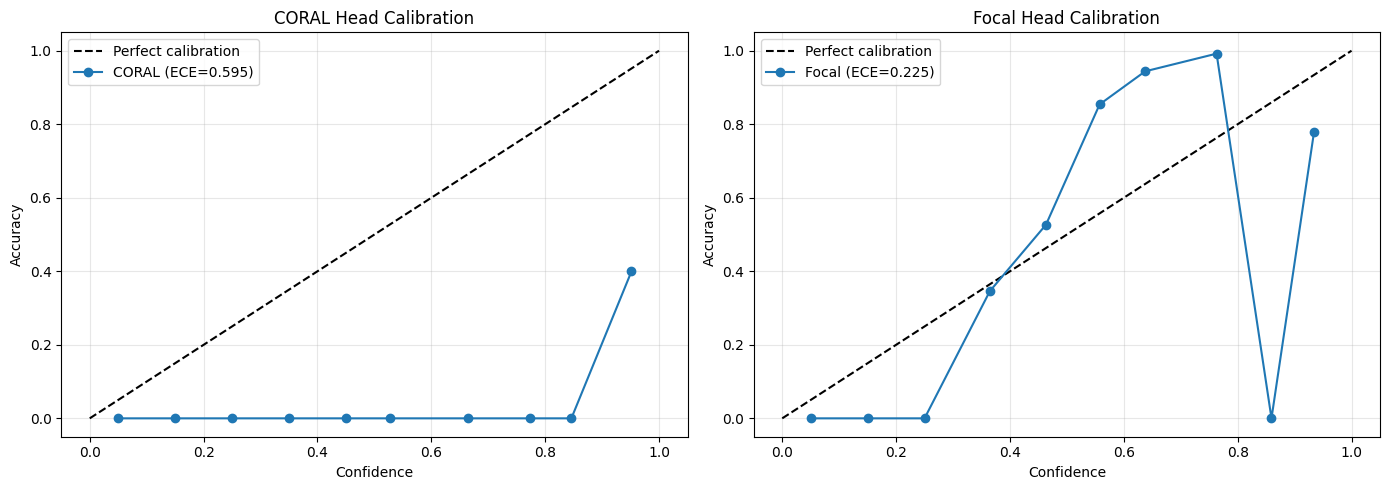

In [25]:
# Plot calibration curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CORAL calibration
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(
    coral_calibration.reliability_diagram['bin_confidences'],
    coral_calibration.reliability_diagram['bin_accuracies'],
    'o-',
    label=f'CORAL (ECE={coral_calibration.ece:.3f})'
)
ax.set_xlabel('Confidence')
ax.set_ylabel('Accuracy')
ax.set_title('CORAL Head Calibration')
ax.legend()
ax.grid(True, alpha=0.3)

# Focal calibration
ax = axes[1]
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(
    focal_calibration.reliability_diagram['bin_confidences'],
    focal_calibration.reliability_diagram['bin_accuracies'],
    'o-',
    label=f'Focal (ECE={focal_calibration.ece:.3f})'
)
ax.set_xlabel('Confidence')
ax.set_ylabel('Accuracy')
ax.set_title('Focal Head Calibration')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Selective Prediction Analysis

How does accuracy improve as we defer more low-confidence predictions?

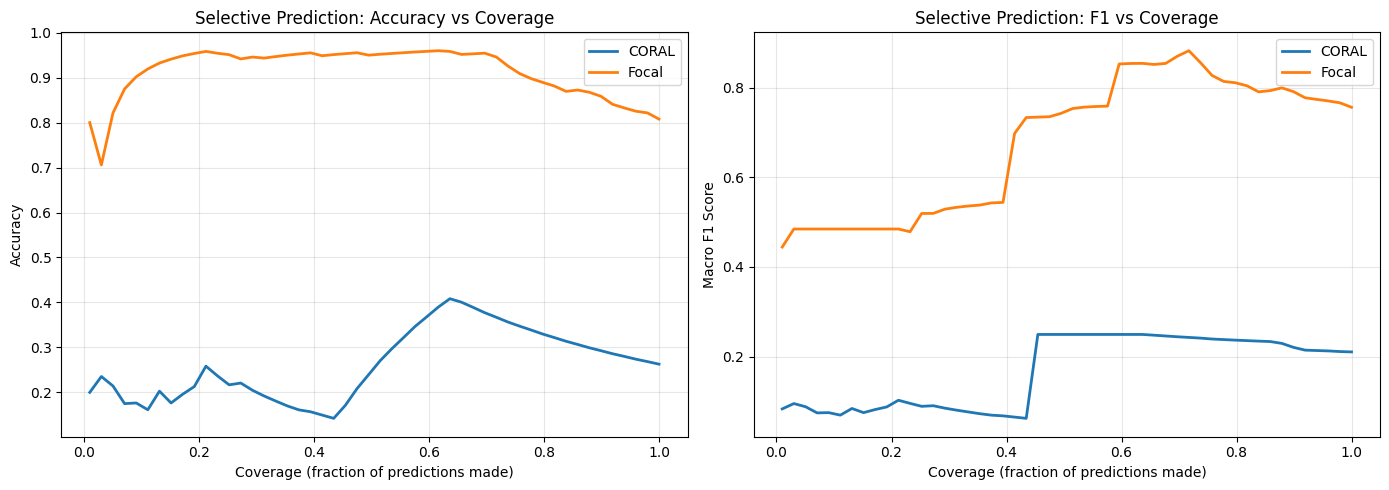


Target accuracy of 95.0% not achievable.
  Best accuracy: 40.8% at coverage 63.6%


In [26]:
# Compute selective prediction curves
# Get predicted classes from probabilities
test_coral_preds = test_coral_probs.argmax(dim=1)
test_focal_preds = test_focal_probs.argmax(dim=1)

# Compute selective metrics (n_points=50 for granular curves)
coral_selective = compute_selective_metrics(
    probs=test_coral_probs,
    predictions=test_coral_preds,
    labels=test_labels,
    n_points=50
)
focal_selective = compute_selective_metrics(
    probs=test_focal_probs,
    predictions=test_focal_preds,
    labels=test_labels,
    n_points=50
)

# Plot selective accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs coverage
ax = axes[0]
ax.plot(coral_selective.coverages, coral_selective.accuracies, label='CORAL', linewidth=2)
ax.plot(focal_selective.coverages, focal_selective.accuracies, label='Focal', linewidth=2)
ax.set_xlabel('Coverage (fraction of predictions made)')
ax.set_ylabel('Accuracy')
ax.set_title('Selective Prediction: Accuracy vs Coverage')
ax.legend()
ax.grid(True, alpha=0.3)

# F1 Score vs coverage
ax = axes[1]
ax.plot(coral_selective.coverages, coral_selective.f1_scores, label='CORAL', linewidth=2)
ax.plot(focal_selective.coverages, focal_selective.f1_scores, label='Focal', linewidth=2)
ax.set_xlabel('Coverage (fraction of predictions made)')
ax.set_ylabel('Macro F1 Score')
ax.set_title('Selective Prediction: F1 vs Coverage')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find coverage needed for target accuracy
target_accuracy = 0.95
optimal_idx = np.argmax(coral_selective.accuracies >= target_accuracy)
if coral_selective.accuracies[optimal_idx] >= target_accuracy:
    print(f"\nTo achieve {target_accuracy:.1%} accuracy with CORAL:")
    print(f"  Coverage: {coral_selective.coverages[optimal_idx]:.1%}")
    print(f"  Defer rate: {1 - coral_selective.coverages[optimal_idx]:.1%}")
    print(f"  Actual accuracy: {coral_selective.accuracies[optimal_idx]:.1%}")
else:
    print(f"\nTarget accuracy of {target_accuracy:.1%} not achievable.")
    print(f"  Best accuracy: {coral_selective.accuracies.max():.1%} at coverage {coral_selective.coverages[coral_selective.accuracies.argmax()]:.1%}")

## 11. Drift Detection Analysis

Check for out-of-distribution nodes based on embedding distance to indexed regime centroids.


Drift Detection Analysis

Drift statistics (k-NN distance):
  Mean distance: 0.001
  Std distance: 0.007
  Max distance: 0.083
  Drift threshold (adaptive): 0.570

Nodes flagged as OOD: 0 (0.0%)


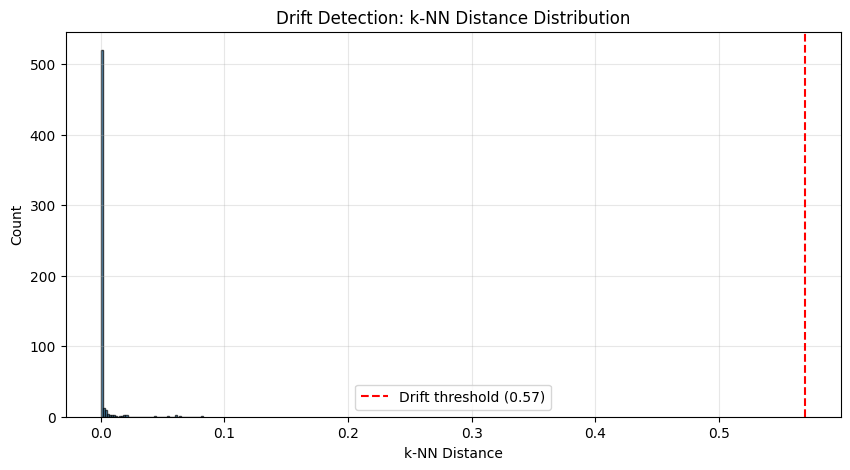

In [27]:
# Get drift detection info for test nodes
test_embeddings = embeddings[test_mask].cpu().numpy()
drift_mask, knn_distances = predictor.regime_detector.detect_drift(test_embeddings, k=5)

# Compute the adaptive drift threshold (same as used in detect_drift)
all_radii = [info.radius for info in predictor.regime_detector.regime_info.values()]
all_stds = [info.std for info in predictor.regime_detector.regime_info.values()]
drift_threshold = np.mean(all_radii) + 2 * np.mean(all_stds)

# Convert to torch tensors for easier manipulation
drift_mask = torch.from_numpy(drift_mask)
knn_distances = torch.from_numpy(knn_distances)

print("\n" + "="*60)
print("Drift Detection Analysis")
print("="*60)
print(f"\nDrift statistics (k-NN distance):")
print(f"  Mean distance: {knn_distances.mean():.3f}")
print(f"  Std distance: {knn_distances.std():.3f}")
print(f"  Max distance: {knn_distances.max():.3f}")
print(f"  Drift threshold (adaptive): {drift_threshold:.3f}")

# Count drifted nodes
print(f"\nNodes flagged as OOD: {drift_mask.sum().item()} ({100*drift_mask.float().mean():.1f}%)")

if drift_mask.sum() > 0:
    # Accuracy on drifted vs non-drifted
    drifted_labels = test_labels[drift_mask]
    drifted_preds = test_predictions[drift_mask]
    drifted_accuracy = (drifted_preds == drifted_labels).float().mean()
    
    non_drifted = ~drift_mask
    non_drifted_labels = test_labels[non_drifted]
    non_drifted_preds = test_predictions[non_drifted]
    non_drifted_accuracy = (non_drifted_preds == non_drifted_labels).float().mean()
    
    print(f"\nAccuracy comparison:")
    print(f"  In-distribution: {non_drifted_accuracy:.4f}")
    print(f"  Out-of-distribution: {drifted_accuracy:.4f}")
    print(f"  Difference: {non_drifted_accuracy - drifted_accuracy:+.4f}")

print("="*60)

# Plot drift distance distribution
plt.figure(figsize=(10, 5))
plt.hist(knn_distances.numpy(), bins=50, alpha=0.7, edgecolor='black')
plt.axvline(drift_threshold, color='red', linestyle='--', 
            label=f'Drift threshold ({drift_threshold:.2f})')
plt.xlabel('k-NN Distance')
plt.ylabel('Count')
plt.title('Drift Detection: k-NN Distance Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Explainability: Get Neighbors for Uncertain Predictions

For nodes with low confidence or deferred predictions, retrieve similar nodes from the training set.

In [29]:
# Get explanations for uncertain predictions (e.g., bottom 10% confidence in test set)
uncertain_threshold = test_confidences.quantile(0.1)
uncertain_mask_test = test_confidences < uncertain_threshold
num_uncertain = uncertain_mask_test.sum().item()

print(f"\nAnalyzing {num_uncertain} uncertain predictions (bottom 10% confidence)...\n")

if num_uncertain > 0:
    # Convert test mask + uncertain mask to global indices
    test_indices = torch.where(test_mask)[0]
    uncertain_test_indices = test_indices[uncertain_mask_test]
    
    explanations = predictor.explain_predictions(data, output, indices=uncertain_test_indices.tolist())
    
    # Show first 5 examples
    print("="*60)
    print("Example Explanations for Uncertain Predictions")
    print("="*60)
    
    for i, exp in enumerate(explanations[:5]):
        print(f"\nExample {i+1}:")
        print(f"  Node ID: {exp.node_id}")
        print(f"  Prediction: {exp.prediction}")
        print(f"  Confidence: {exp.confidence:.3f}")
        print(f"  Expected value: {exp.expected_value:.3f}")
        print(f"  Decision: {exp.decision}")
        print(f"  Regime distance: {exp.regime_distance:.3f}" if exp.regime_distance is not None else "  Regime distance: N/A")
        print(f"  Is drift: {exp.is_drift}")
        print(f"\n  Top 3 similar nodes:")
        for j, neighbor in enumerate(exp.neighbors[:3]):
            print(f"    {j+1}. Label {neighbor['label']}, distance {neighbor['distance']:.3f}")
    
    print("="*60)
    
    # Summary statistics
    decisions = [exp.decision for exp in explanations]
    print("\nDecision distribution for uncertain predictions:")
    from collections import Counter
    decision_counts = Counter(decisions)
    for decision, count in decision_counts.most_common():
        print(f"  {decision}: {count} ({100*count/len(decisions):.1f}%)")


Analyzing 50 uncertain predictions (bottom 10% confidence)...

Example Explanations for Uncertain Predictions

Example 1:
  Node ID: 4:f994f8c7-9de5-4257-9a97-b87758ae94bf:1029276
  Prediction: 4
  Confidence: 0.500
  Expected value: 2.020
  Decision: defer
  Regime distance: 0.295
  Is drift: False

  Top 3 similar nodes:
    1. Label 1, distance 0.000
    2. Label 1, distance 0.000
    3. Label 1, distance 0.000

Example 2:
  Node ID: 4:f994f8c7-9de5-4257-9a97-b87758ae94bf:1029276
  Prediction: 4
  Confidence: 0.500
  Expected value: 2.020
  Decision: defer
  Regime distance: 0.295
  Is drift: False

  Top 3 similar nodes:
    1. Label 1, distance 0.000
    2. Label 1, distance 0.000
    3. Label 1, distance 0.000

Example 3:
  Node ID: 4:f994f8c7-9de5-4257-9a97-b87758ae94bf:1029276
  Prediction: 4
  Confidence: 0.500
  Expected value: 2.020
  Decision: defer
  Regime distance: 0.295
  Is drift: False

  Top 3 similar nodes:
    1. Label 1, distance 0.000
    2. Label 1, distance 0.

## 13. Compare Heads: When Do CORAL and Focal Agree/Disagree?

In [30]:
# Get predictions from both heads
coral_preds = test_coral_probs.argmax(dim=1)
focal_preds = test_focal_probs.argmax(dim=1)

# Agreement analysis
agreement = (coral_preds == focal_preds).float()
coral_correct = (coral_preds == test_labels).float()
focal_correct = (focal_preds == test_labels).float()

print("\n" + "="*60)
print("Head Comparison: CORAL vs Focal")
print("="*60)
print(f"\nOverall agreement: {agreement.mean():.1%}")
print(f"\nIndividual accuracies:")
print(f"  CORAL: {coral_correct.mean():.4f}")
print(f"  Focal: {focal_correct.mean():.4f}")

# When do they disagree?
disagree_mask = coral_preds != focal_preds
if disagree_mask.sum() > 0:
    print(f"\nDisagreement cases: {disagree_mask.sum().item()} ({100*disagree_mask.float().mean():.1f}%)")
    
    # Who is correct when they disagree?
    disagree_coral_correct = coral_correct[disagree_mask].mean()
    disagree_focal_correct = focal_correct[disagree_mask].mean()
    print(f"\nWhen they disagree:")
    print(f"  CORAL correct: {disagree_coral_correct:.1%}")
    print(f"  Focal correct: {disagree_focal_correct:.1%}")
    
    # Confidence when they disagree
    disagree_coral_conf = test_coral_probs[disagree_mask].max(dim=1).values.mean()
    disagree_focal_conf = test_focal_probs[disagree_mask].max(dim=1).values.mean()
    print(f"\n  CORAL confidence: {disagree_coral_conf:.3f}")
    print(f"  Focal confidence: {disagree_focal_conf:.3f}")

print("="*60)


Head Comparison: CORAL vs Focal

Overall agreement: 27.7%

Individual accuracies:
  CORAL: 0.2628
  Focal: 0.8078

Disagreement cases: 410 (72.3%)

When they disagree:
  CORAL correct: 4.4%
  Focal correct: 79.8%

  CORAL confidence: 0.833
  Focal confidence: 0.564


## 14. Visualize Routing Decisions

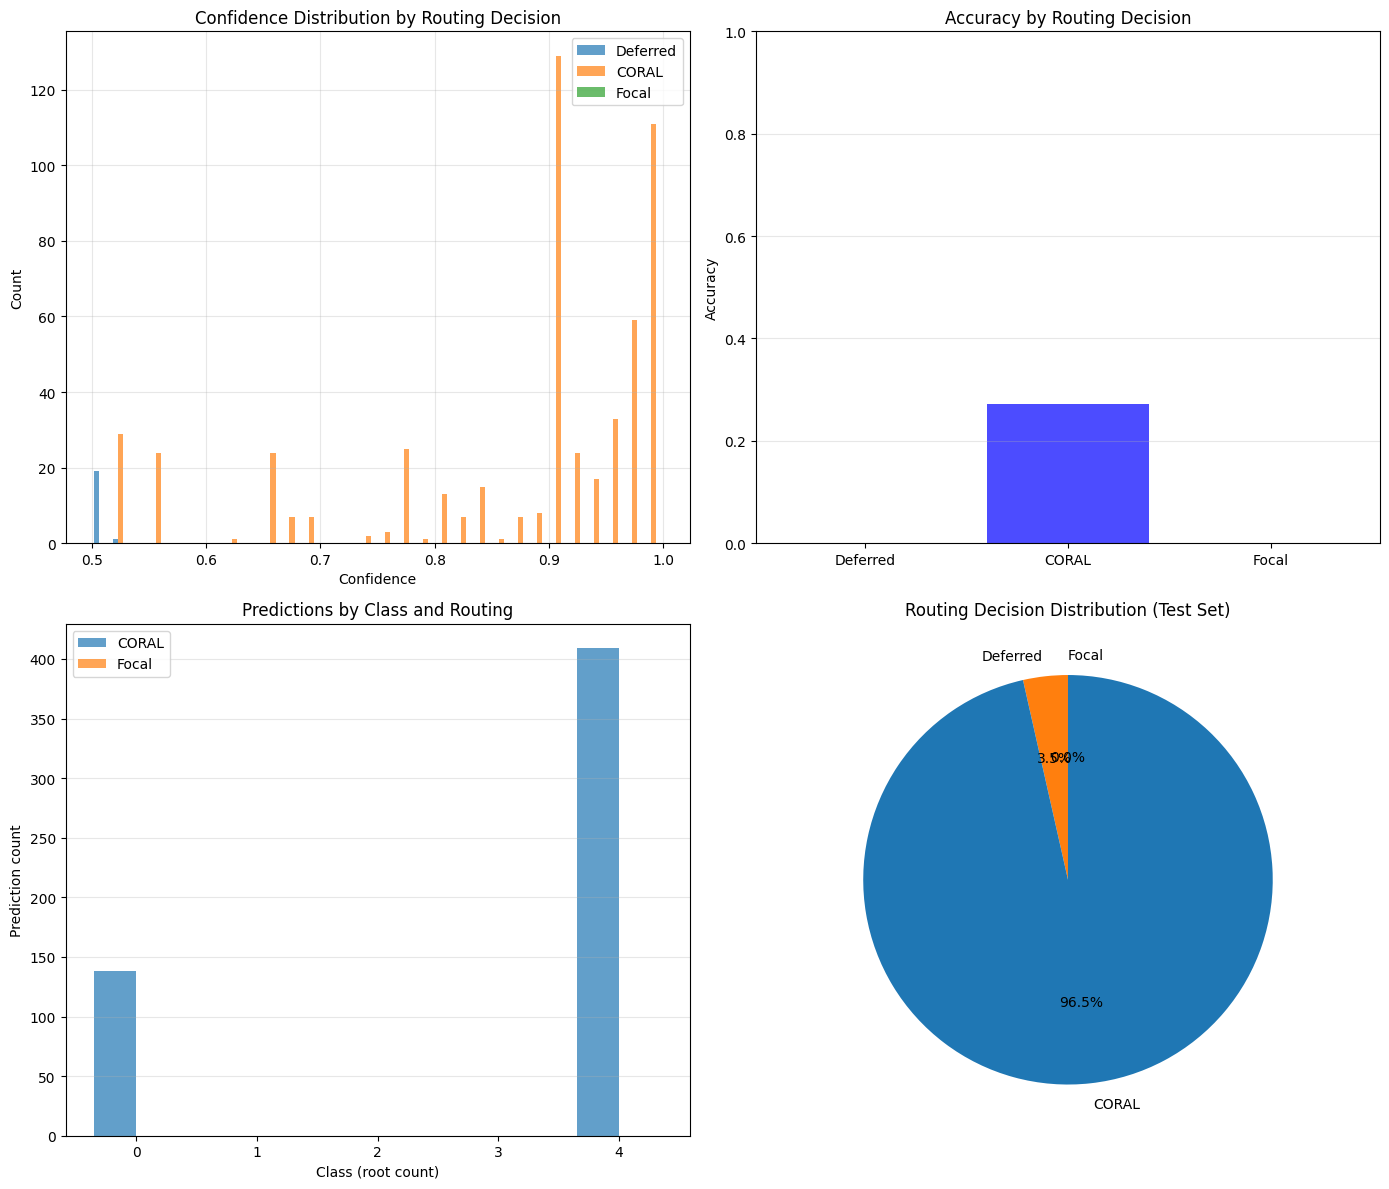

In [31]:
# Create visualization of routing decisions (test set)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confidence distribution by routing decision
ax = axes[0, 0]
defer_conf = test_confidences[test_defer_mask].cpu().numpy()
ordinal_conf = test_confidences[test_ordinal_mask].cpu().numpy()
focal_conf = test_confidences[test_focal_mask].cpu().numpy()

ax.hist([defer_conf, ordinal_conf, focal_conf], bins=30, label=['Deferred', 'CORAL', 'Focal'], alpha=0.7)
ax.set_xlabel('Confidence')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution by Routing Decision')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Accuracy by routing decision
ax = axes[0, 1]
decisions = ['Deferred', 'CORAL', 'Focal']
test_labels_cpu = data.y[test_mask].cpu()
accuracies_by_decision = []
for mask in [test_defer_mask, test_ordinal_mask, test_focal_mask]:
    if mask.sum() > 0:
        acc = (test_predictions[mask].cpu() == test_labels_cpu[mask]).float().mean().item()
        accuracies_by_decision.append(acc)
    else:
        accuracies_by_decision.append(0)

ax.bar(decisions, accuracies_by_decision, alpha=0.7, color=['red', 'blue', 'green'])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Routing Decision')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# 3. Prediction count by class and routing
ax = axes[1, 0]
classes = torch.unique(data.y).numpy()
coral_class_counts = torch.bincount(test_predictions[test_ordinal_mask].cpu(), minlength=len(classes)).numpy()
focal_class_counts = torch.bincount(test_predictions[test_focal_mask].cpu(), minlength=len(classes)).numpy()

x = np.arange(len(classes))
width = 0.35
ax.bar(x - width/2, coral_class_counts, width, label='CORAL', alpha=0.7)
ax.bar(x + width/2, focal_class_counts, width, label='Focal', alpha=0.7)
ax.set_xlabel('Class (root count)')
ax.set_ylabel('Prediction count')
ax.set_title('Predictions by Class and Routing')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Routing decision pie chart
ax = axes[1, 1]
routing_counts = [
    test_defer_mask.sum().item(),
    test_ordinal_mask.sum().item(),
    test_focal_mask.sum().item()
]
colors = ['#ff7f0e', '#1f77b4', '#2ca02c']
ax.pie(routing_counts, labels=decisions, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Routing Decision Distribution (Test Set)')

plt.tight_layout()
plt.show()

## 15. Summary Report

In [32]:
print("\n" + "="*80)
print(" "*20 + "PRODUCTION SYSTEM SUMMARY REPORT")
print("="*80)

print("\n📊 DATA:")
print(f"  Total nodes: {data.num_nodes:,}")
print(f"  Test set size: {test_mask.sum().item():,}")
print(f"  Number of classes: {len(torch.unique(data.y))}")

print("\n🎯 MODEL PERFORMANCE:")
print(f"  Phase 1 (CORAL) Test F1: {metrics['phase1']['test_macro_f1']:.4f}")
print(f"  Phase 2 (Focal) Test F1: {metrics['phase2']['test_macro_f1']:.4f}")

print("\n🔀 ROUTING DECISIONS (Test Set):")
print(f"  Deferred: {test_defer_mask.sum().item()} ({100*test_defer_mask.float().mean():.1f}%)")
print(f"  Used CORAL: {test_ordinal_mask.sum().item()} ({100*test_ordinal_mask.float().mean():.1f}%)")
print(f"  Used Focal: {test_focal_mask.sum().item()} ({100*test_focal_mask.float().mean():.1f}%)")

non_deferred_test = ~test_defer_mask
if non_deferred_test.sum() > 0:
    accuracy = (test_predictions[non_deferred_test] == data.y[test_mask][non_deferred_test]).float().mean()
    print(f"\n  Accuracy on non-deferred: {accuracy:.4f}")

print("\n📏 CALIBRATION:")
print(f"  CORAL ECE: {coral_calibration.ece:.4f}")
print(f"  Focal ECE: {focal_calibration.ece:.4f}")
print(f"  Mean confidence (test): {test_confidences.mean():.3f}")

print("\n🌊 DRIFT DETECTION:")
print(f"  OOD nodes: {drift_mask.sum().item()} ({100*drift_mask.float().mean():.1f}%)")
print(f"  Mean k-NN distance: {knn_distances.mean():.3f}")
print(f"  Drift threshold (adaptive): {drift_threshold:.3f}")

print("\n🤝 HEAD AGREEMENT:")
print(f"  CORAL vs Focal agreement: {agreement.mean():.1%}")
print(f"  CORAL accuracy: {coral_correct.mean():.4f}")
print(f"  Focal accuracy: {focal_correct.mean():.4f}")

print("\n✅ PRODUCTION READINESS:")
readiness_checks = [
    ("Two-phase training complete", True),
    ("Regime detector fitted", predictor.regime_detector is not None),
    ("Router configured", predictor.router is not None),
    ("Calibration analyzed", coral_calibration.ece < 0.15),
    ("Drift monitoring active", True),
]

for check, status in readiness_checks:
    symbol = "✓" if status else "✗"
    print(f"  {symbol} {check}")

print("\n" + "="*80)
print("\n🎉 Production system is ready for deployment!")
print("\nNext steps:")
print("  1. Save model checkpoint: torch.save(model.state_dict(), 'production_model.pt')")
print("  2. Save regime detector: predictor.regime_detector.save('regime_detector.pkl')")
print("  3. Deploy predictor with routing configuration")
print("  4. Monitor drift and calibration in production")
print("  5. Set up alerting for high defer rates or drift")
print("="*80)


                    PRODUCTION SYSTEM SUMMARY REPORT

📊 DATA:
  Total nodes: 3,775
  Test set size: 567
  Number of classes: 5

🎯 MODEL PERFORMANCE:
  Phase 1 (CORAL) Test F1: 0.2105
  Phase 2 (Focal) Test F1: 0.7563

🔀 ROUTING DECISIONS (Test Set):
  Deferred: 20 (3.5%)
  Used CORAL: 547 (96.5%)
  Used Focal: 0 (0.0%)

  Accuracy on non-deferred: 0.2724

📏 CALIBRATION:
  CORAL ECE: 0.5953
  Focal ECE: 0.2255
  Mean confidence (test): 0.858

🌊 DRIFT DETECTION:
  OOD nodes: 0 (0.0%)
  Mean k-NN distance: 0.001
  Drift threshold (adaptive): 0.570

🤝 HEAD AGREEMENT:
  CORAL vs Focal agreement: 27.7%
  CORAL accuracy: 0.2628
  Focal accuracy: 0.8078

✅ PRODUCTION READINESS:
  ✓ Two-phase training complete
  ✓ Regime detector fitted
  ✓ Router configured
  ✗ Calibration analyzed
  ✓ Drift monitoring active


🎉 Production system is ready for deployment!

Next steps:
  1. Save model checkpoint: torch.save(model.state_dict(), 'production_model.pt')
  2. Save regime detector: predictor.regime_

## 16. (Optional) Write Predictions to Neo4j

Uncomment and run this cell to write the production predictions back to Neo4j.

In [ ]:
# # Write predictions to Neo4j
# from graph_label_prediction.python_model.core.predictor import NodePredictor

# # Create node predictor for write-back (use model's device)
# device = next(model.parameters()).device
# node_predictor = NodePredictor(model, device=device)

# # Write predictions (add production_ prefix to distinguish from other predictions)
# stats = node_predictor.predict_and_write(
#     data=data,
#     client=client,
#     database=NEO4J_DATABASE,
#     prediction_property='production_predicted_roots',
#     probability_property='production_prediction_probs'
# )

# print("\n✓ Predictions written to Neo4j")
# print(f"  Property: production_predicted_roots")
# print(f"  Nodes updated: {stats['nodes_updated']}")

## 17. Cleanup

In [ ]:
# Close Neo4j connection
client.close()
print("✓ Neo4j connection closed")